In [12]:
import json
import random
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import textstat
import re
from better_profanity import profanity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression

In [ ]:
df = pd.read_pickle("../data/data_final_features.pkl")

,Index,author,body,normalizedBody,content,content_len,summary,summary_len,id,subreddit,...,content_profanity,summary_profanity,delta_profanity,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,delta_sentiment,delta_subjectivity,entity_retention_rate
0,90,Occamsrazor1,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,Every basic ecology class teaches this. The id...,112,We need to stop being such selfish bastards,8,c6hj5o3,science,...,0,0,0,0.2040,-0.8519,0.397338,0.750000,-1.0559,0.352662,0.0
1,91,Suddenfury,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,i was thinking about exactly this just yesterd...,148,why are the fishfarm industry so small scale?,8,c6hml12,science,...,0,0,0,0.6075,0.0000,0.480427,0.400000,-0.6075,-0.080427,0.0
2,104,flutterbug32,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,One thing I have been told multiple times is t...,270,who you know is more helpful sometimes than wh...,11,c6rgfy8,ecology,...,0,0,0,0.9932,0.4754,0.482919,0.500000,-0.5178,0.017081,0.0
3,226,champyonfiyah,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,I'll take a crack at this. Starting with: ...,213,Yes you can do that with an arduino.,8,c6v4cup,arduino,...,0,0,0,0.9910,0.4019,0.542587,0.000000,-0.5891,-0.542587,0.0
4,300,Destructor1701,The *apparent* size - which is a function of s...,The apparent size - which is a function of s...,The apparent size - which is a function of s...,97,Distance matters only as part of the function ...,24,c71qcs8,space,...,0,0,0,0.2433,0.0258,0.550694,0.450000,-0.2175,-0.100694,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83659,3848327,an00bisX,"Long time lurker, first time poster here. I'm ...","Long time lurker, first time poster here. I'm ...","Long time lurker, first time poster here. I'm ...",435,"want cash prize, need answer for radio contest...",9,t3_fbmsr,AskReddit,...,0,0,0,0.4767,0.5574,0.374206,0.000000,0.0807,-0.374206,0.0
83660,3796016,VapedScoops,You may have seen my post a few days back abou...,You may have seen my post a few days back abou...,You may have seen my post a few days back abou...,199,always have a backup for your backup's backup.,8,t3_3q21vd,electronic_cigarette,...,1,0,-1,-0.9027,0.0000,0.492210,0.000000,0.9027,-0.492210,0.0
83661,3655109,nomechinguex,I get no karma for these so please upvote\n\nT...,I get no karma for these so please upvote \n T...,I get no karma for these so please upvote \n T...,130,If reddit ever closes all these wonderfull thr...,18,t3_xfdbu,AskReddit,...,0,0,0,0.9332,-0.3182,0.555093,0.000000,-1.2514,-0.555093,0.0
83662,3822480,thatonecuriousguy,"Hi everyone, I'm a 22 year old guy who goes to...","Hi everyone, I'm a 22 year old guy who goes to...","Hi everyone, I'm a 22 year old guy who goes to...",175,had little luck dating in college so far. What...,18,t3_4epvie,relationships,...,0,0,0,0.9893,0.4033,0.555911,0.633333,-0.5860,0.077423,0.0


                              content_flesch_reading_ease  \
content_flesch_reading_ease                          1.00   
content_flesch_kincaid_grade                        -0.90   
content_gunning_fog                                 -0.89   
content_coleman_liau                                -0.85   

                              content_flesch_kincaid_grade  \
content_flesch_reading_ease                          -0.90   
content_flesch_kincaid_grade                          1.00   
content_gunning_fog                                   0.98   
content_coleman_liau                                  0.62   

                              content_gunning_fog  content_coleman_liau  
content_flesch_reading_ease                 -0.89                 -0.85  
content_flesch_kincaid_grade                 0.98                  0.62  
content_gunning_fog                          1.00                  0.62  
content_coleman_liau                         0.62                  1.00  


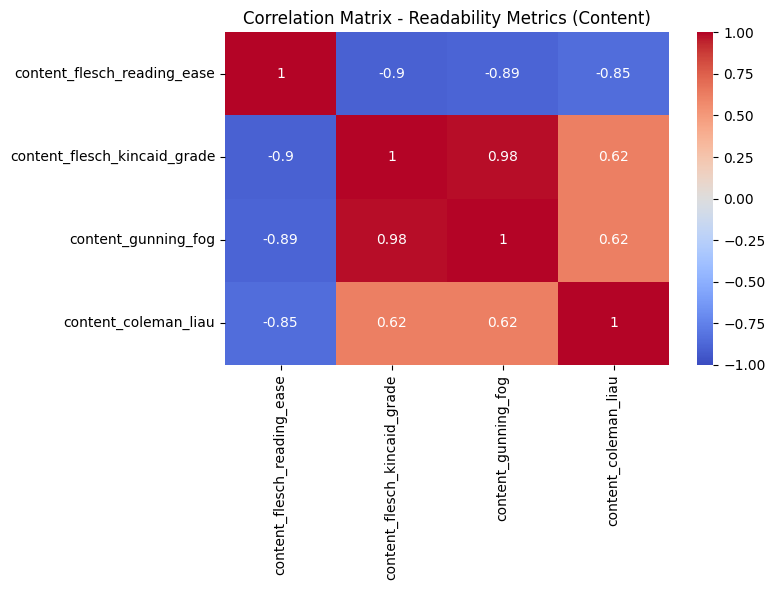

In [4]:
# check readability features again and select one

readability_cols = [
    'content_flesch_reading_ease', 'content_flesch_kincaid_grade',
    'content_gunning_fog', 'content_coleman_liau'
]

corr_matrix_readability = df[readability_cols].corr().round(2)
print(corr_matrix_readability)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_readability, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Readability Metrics (Content)')
plt.tight_layout()
plt.show()

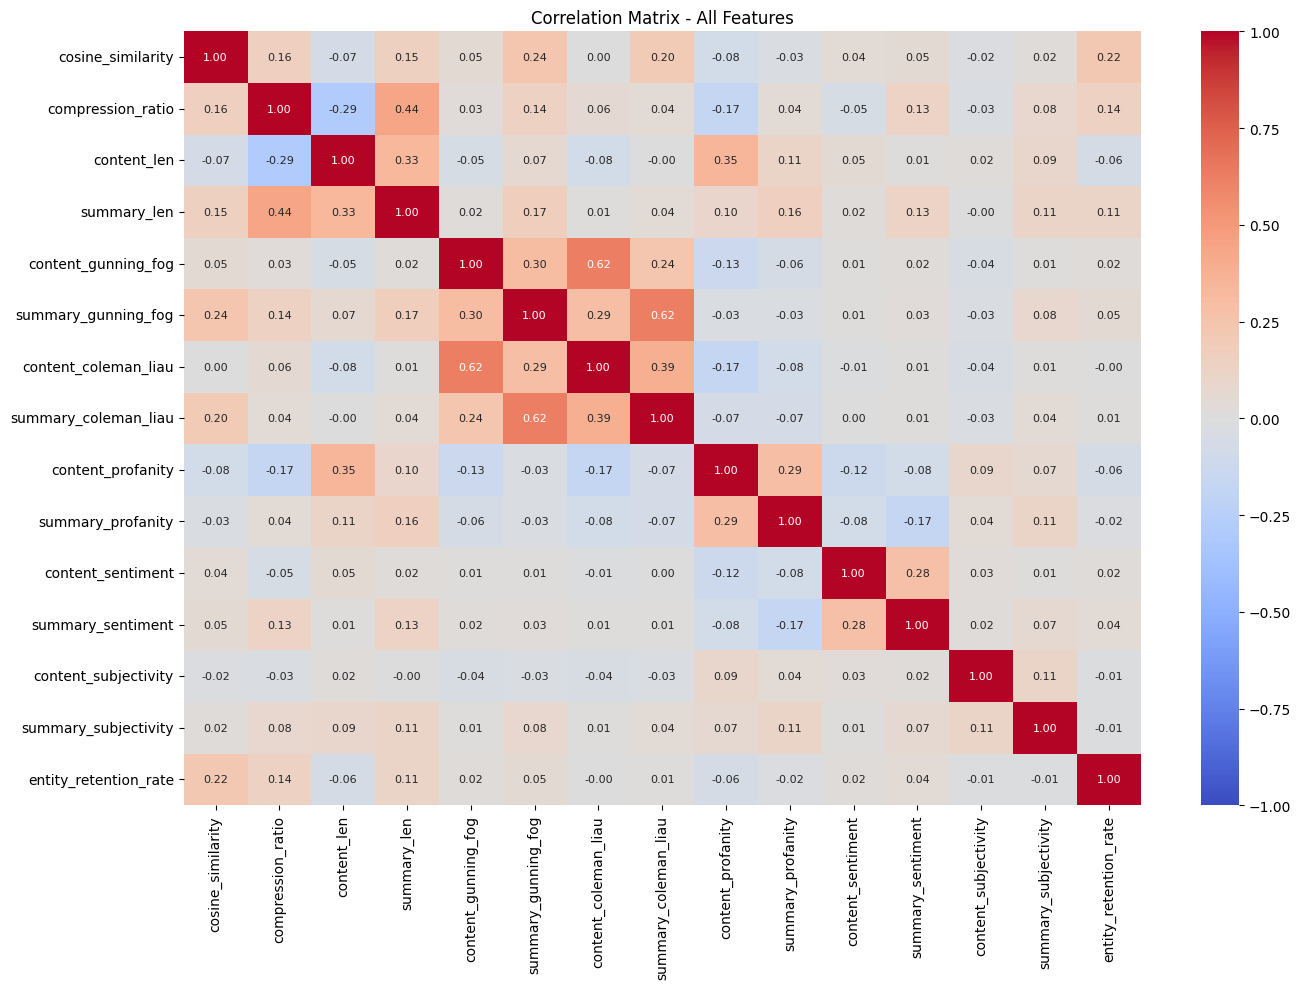

,cosine_similarity,compression_ratio,content_len,summary_len,content_gunning_fog,summary_gunning_fog,content_coleman_liau,summary_coleman_liau,content_profanity,summary_profanity,content_sentiment,summary_sentiment,content_subjectivity,summary_subjectivity,entity_retention_rate
cosine_similarity,1.00,0.16,-0.07,0.15,0.05,0.24,0.00,0.20,-0.08,-0.03,0.04,0.05,-0.02,0.02,0.22
compression_ratio,0.16,1.00,-0.29,0.44,0.03,0.14,0.06,0.04,-0.17,0.04,-0.05,0.13,-0.03,0.08,0.14
content_len,-0.07,-0.29,1.00,0.33,-0.05,0.07,-0.08,-0.00,0.35,0.11,0.05,0.01,0.02,0.09,-0.06
summary_len,0.15,0.44,0.33,1.00,0.02,0.17,0.01,0.04,0.10,0.16,0.02,0.13,-0.00,0.11,0.11
content_gunning_fog,0.05,0.03,-0.05,0.02,1.00,0.30,0.62,0.24,-0.13,-0.06,0.01,0.02,-0.04,0.01,0.02
summary_gunning_fog,0.24,0.14,0.07,0.17,0.30,1.00,0.29,0.62,-0.03,-0.03,0.01,0.03,-0.03,0.08,0.05
content_coleman_liau,0.00,0.06,-0.08,0.01,0.62,0.29,1.00,0.39,-0.17,-0.08,-0.01,0.01,-0.04,0.01,-0.00
summary_coleman_liau,0.20,0.04,-0.00,0.04,0.24,0.62,0.39,1.00,-0.07,-0.07,0.00,0.01,-0.03,0.04,0.01
content_profanity,-0.08,-0.17,0.35,0.10,-0.13,-0.03,-0.17,-0.07,1.00,0.29,-0.12,-0.08,0.09,0.07,-0.06
summary_profanity,-0.03,0.04,0.11,0.16,-0.06,-0.03,-0.08,-0.07,0.29,1.00,-0.08,-0.17,0.04,0.11,-0.02


In [6]:
# check collinearity of other features
feature_cols = [
    'cosine_similarity', 'compression_ratio', 'content_len', 'summary_len',
    'content_gunning_fog', 'summary_gunning_fog',
    'content_coleman_liau', 'summary_coleman_liau',
    'content_profanity', 'summary_profanity',
    'content_sentiment', 'summary_sentiment',
    'content_subjectivity', 'summary_subjectivity',
    'entity_retention_rate'
]

corr_matrix = df[feature_cols].corr().round(2)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Matrix - All Features')
plt.tight_layout()
plt.show()
corr_matrix

In [10]:
df.columns.tolist()

['Index',
 'author',
 'body',
 'normalizedBody',
 'content',
 'content_len',
 'summary',
 'summary_len',
 'id',
 'subreddit',
 'subreddit_id',
 'title',
 'is_science',
 'cosine_similarity',
 'content_flesch_reading_ease',
 'content_flesch_kincaid_grade',
 'content_gunning_fog',
 'content_coleman_liau',
 'summary_flesch_reading_ease',
 'summary_flesch_kincaid_grade',
 'summary_gunning_fog',
 'summary_coleman_liau',
 'delta_flesch_reading_ease',
 'delta_flesch_kincaid_grade',
 'delta_gunning_fog',
 'delta_coleman_liau',
 'content_alpha_ratio',
 'compression_ratio',
 'content_profanity',
 'summary_profanity',
 'delta_profanity',
 'content_sentiment',
 'summary_sentiment',
 'content_subjectivity',
 'summary_subjectivity',
 'delta_sentiment',
 'delta_subjectivity',
 'entity_retention_rate']

In [40]:
FOLDS = 10

y = df["is_science"].astype(int)

colnames_summary = ["summary_len", "summary_gunning_fog", "summary_coleman_liau", "summary_profanity", "summary_sentiment", "summary_subjectivity"]
colnames_content = ["content_len", "content_gunning_fog", "content_coleman_liau", "content_profanity", "content_sentiment", "content_subjectivity"]
colnames_full = colnames_content + colnames_summary + ["cosine_similarity", "entity_retention_rate"]

X_summary = df[colnames_summary]
X_content = df[colnames_content]
X_full = df[colnames_full]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter = 1000))
])

cv = StratifiedKFold(n_splits = FOLDS, shuffle = True, random_state = 42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

summary_cv_results = cross_validate(pipeline, X_summary, y, cv=cv, scoring=scoring)
content_cv_results = cross_validate(pipeline, X_content, y, cv=cv, scoring=scoring)
full_cv_results = cross_validate(pipeline, X_full, y, cv=cv, scoring=scoring)

cv_df = pd.DataFrame({
    "Model": ["Summary only", "Content only", "Full"],
    "Accuracy": [summary_cv_results["test_accuracy"].mean(), content_cv_results["test_accuracy"].mean(), full_cv_results["test_accuracy"].mean()],
    "Precision": [summary_cv_results["test_precision"].mean(), content_cv_results["test_precision"].mean(), full_cv_results["test_precision"].mean()],
    "Recall": [summary_cv_results["test_recall"].mean(), content_cv_results["test_recall"].mean(), full_cv_results["test_recall"].mean()],
    "F1-Score": [summary_cv_results["test_f1"].mean(), content_cv_results["test_f1"].mean(), full_cv_results["test_f1"].mean()],
    "ROC-AUC": [summary_cv_results["test_roc_auc"].mean(), content_cv_results["test_roc_auc"].mean(), full_cv_results["test_roc_auc"].mean()]
}
)

display(cv_df)

# Model Summary

# standardizing
scaler = StandardScaler()
x_summary_scaled = pd.DataFrame(scaler.fit_transform(X_summary), columns = X_summary.columns, index = X_summary.index)
x_content_scaled = pd.DataFrame(scaler.fit_transform(X_content), columns = X_content.columns, index = X_content.index)
x_full_scaled = pd.DataFrame(scaler.fit_transform(X_full), columns = X_full.columns, index = X_full.index)

# adding oonstants
X_summary_sm = sm.add_constant(x_summary_scaled) 
X_content_sm = sm.add_constant(x_content_scaled) 
X_full_sm = sm.add_constant(x_full_scaled) 

# models:
logit_summary = sm.Logit(y, X_summary_sm)
logit_content = sm.Logit(y, X_content_sm)
logit_full = sm.Logit(y, X_full_sm)

# results
result_summary = logit_summary.fit()
result_content = logit_content.fit()
result_full = logit_full.fit()

print("\nLogit Model: Summary-only")
print(result_summary.summary())
print("|"*80)
print("\nLogit Model: Content-only")
print(result_content.summary())
print("|"*80)
print("\nLogit Model: Full")
print(result_full.summary())
print("|"*80)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Summary only,0.610067,0.609223,0.591705,0.600296,0.651460
1,Content only,0.735493,0.740869,0.716054,0.728210,0.807899
2,Full,0.742807,0.748001,0.724426,0.735993,0.815486


Optimization terminated successfully.
         Current function value: 0.657834
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.543633
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.533869
         Iterations 6

Logit Model: Summary-only
                           Logit Regression Results                           
Dep. Variable:             is_science   No. Observations:                79170
Model:                          Logit   Df Residuals:                    79163
Method:                           MLE   Df Model:                            6
Date:                 Do, 18 Jun 2026   Pseudo R-squ.:                 0.05087
Time:                        15:15:16   Log-Likelihood:                -52081.
converged:                       True   LL-Null:                       -54872.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    

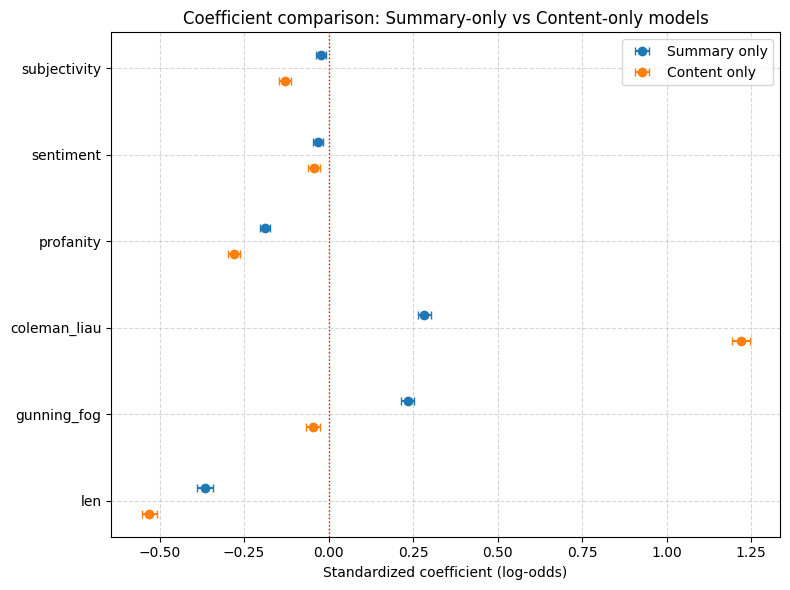

In [54]:
# Coefficient Plot: Comparing Summary-Only and Content-Only Models

def get_coef_df(result, prefix, model_name):
    """Pull coefficients + 95% CIs out of a fitted statsmodels result,
    drop the intercept, and strip the feature-name prefix so that
    e.g. 'summary_len' and 'content_len' both become 'len'."""
    conf = result.conf_int()
    conf.columns = ["ci_low", "ci_high"]
 
    coef_df = pd.DataFrame({
        "feature": result.params.index,
        "coef": result.params.values,
        "ci_low": conf["ci_low"].values,
        "ci_high": conf["ci_high"].values,
    })
 
    coef_df = coef_df[coef_df["feature"] != "const"]
    coef_df["feature"] = coef_df["feature"].str.replace(f"^{prefix}_", "", regex=True)
    coef_df["model"] = model_name
    return coef_df


summary_coefs = get_coef_df(result_summary, "summary", "Summary only")
content_coefs = get_coef_df(result_content, "content", "Content only")

coef_plot_df = pd.concat([summary_coefs, content_coefs], ignore_index=True)


feature_order = summary_coefs["feature"].tolist()
coef_plot_df["feature"] = pd.Categorical(
    coef_plot_df["feature"], categories=feature_order, ordered=True
)
coef_plot_df = coef_plot_df.sort_values("feature")


fig, ax = plt.subplots(figsize=(8, 6))
 
offset = 0.15
colors = {"Summary only": "#1f77b4", "Content only": "#ff7f0e"}
 
for model_name, shift in [("Summary only", offset), ("Content only", -offset)]:
    sub = coef_plot_df[coef_plot_df["model"] == model_name]
    y_positions = np.arange(len(sub)) + shift
    errors = [sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]]
    ax.errorbar(
        sub["coef"], y_positions, xerr=errors,
        fmt="o", label=model_name, color=colors[model_name], capsize=3,
    )
 
ax.axvline(x=0, color="red", linestyle=":", linewidth=1)
ax.set_yticks(np.arange(len(feature_order)))
ax.set_yticklabels(feature_order)
ax.set_xlabel("Standardized coefficient (log-odds)")
ax.set_title("Coefficient comparison: Summary-only vs Content-only models")
ax.legend()
plt.grid(axis = "both", linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

